##Assignment 1 — Exploring FAISS (Local Vector Search)
**Goal:**
Understand how to store, index, and retrieve document embeddings locally using FAISS.

In [1]:
%pip install faiss-cpu sentence-transformers matplotlib seaborn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 44.6 MB/s eta 0:00:00


Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Total documents indexed: 12

Query: How can AI help with renewable energy and solar grids?


,Rank,Distance (L2),Document
0,1,0.493206,Smart grids use artificial intelligence to bal...
1,2,0.772661,AI algorithms predict local weather patterns t...
2,3,0.999943,AI systems manage urban traffic flow to reduce...
3,4,1.150757,Reinforcement learning agents design energy-ef...
4,5,1.193119,Deep learning helps optimize the blade angles ...


/tmp/ipykernel_4075/4228652469.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


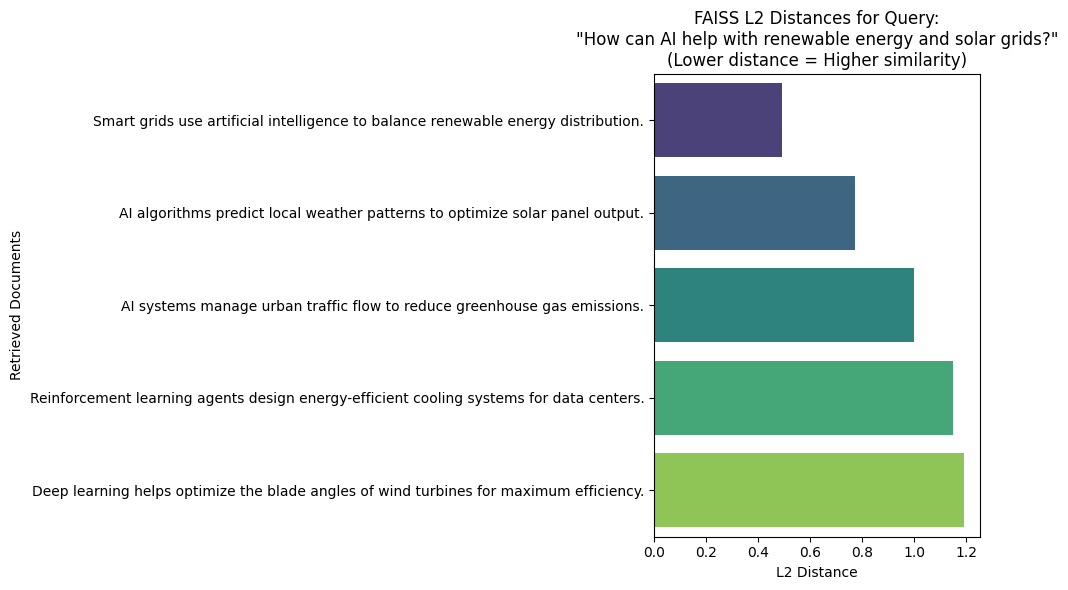

In [2]:
import faiss
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer

# Mini-corpus
corpus = [
    "Machine learning models are used to predict deforestation rates in the Amazon.",
    "AI-driven sensors monitor ocean acidification and coral reef health.",
    "Deep learning helps optimize the blade angles of wind turbines for maximum efficiency.",
    "Smart grids use artificial intelligence to balance renewable energy distribution.",
    "Computer vision drones track endangered species without disrupting their habitats.",
    "Natural language processing analyzes climate policy documents for key trends.",
    "AI algorithms predict local weather patterns to optimize solar panel output.",
    "Reinforcement learning agents design energy-efficient cooling systems for data centers.",
    "Satellite imagery combined with AI tracks illegal fishing activities globally.",
    "Generative AI suggests new molecular structures for biodegradable plastics.",
    "Machine learning models predict the spread of wildfires using climate data.",
    "AI systems manage urban traffic flow to reduce greenhouse gas emissions."
]

# Generate embeddings
print("Loading model")
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(corpus)

# Ensure embeddings are float32 as required by FAISS
embeddings = np.array(embeddings).astype("float32")
dimension = embeddings.shape[1]

# Store them in a FAISS index (IndexFlatL2)
index = faiss.IndexFlatL2(dimension)
index.add(embeddings)
print(f"Total documents indexed: {index.ntotal}")

# Search for the top-k most similar documents
query = "How can AI help with renewable energy and solar grids?"
query_embedding = model.encode([query]).astype("float32")

k = 5 # top-k
distances, indices = index.search(query_embedding, k)

# Extract results
results = []
for i in range(k):
    doc_idx = indices[0][i]
    results.append({
        "Rank": i + 1,
        "Distance (L2)": distances[0][i],
        "Document": corpus[doc_idx]
    })

results_df = pd.DataFrame(results)
print("\nQuery:", query)
display(results_df)

# Plot similarity distances
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Distance (L2)",
    y="Document",
    data=results_df,
    palette="viridis",
    orient="h"
)
plt.title(f'FAISS L2 Distances for Query:\n"{query}"\n(Lower distance = Higher similarity)')
plt.xlabel("L2 Distance")
plt.ylabel("Retrieved Documents")
plt.tight_layout()
plt.show()

#Reflection
**How does L2 distance differ from cosine similarity?** <br>
**Ans:**

*   `L2 Distance` (Euclidean Distance): This measures the straight-line distance between two vectors in space. It considers both the magnitude (length) and the direction of the vectors.
*   `Cosine Similarity`: This measures the cosine of the angle between two vectors, completely ignoring their magnitude. It only cares about orientation.

**How would results change if you normalize embeddings?**
**Ans:** If you normalize the embeddings so that every vector has a length of 1, L2 distance and cosine similarity become mathematically proportional.
Therefore, if you normalize your vectors before passing them to FAISS, using IndexFlatL2 will yield the exact same ranking order as if you had performed a Cosine search.

##Assignment 2 — Building a Mini Knowledge Base with Chroma
Goal:
Learn to build a simple local vector database using Chroma, integrated with embeddings and LangChain.

In [1]:
%pip install chromadb sentence-transformers matplotlib pandas langchain-chroma langchain-huggingface

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

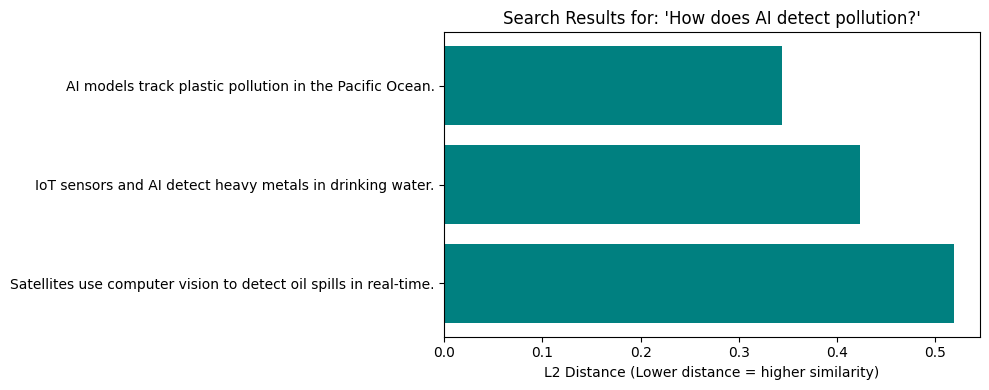

In [2]:
import chromadb
from chromadb.utils import embedding_functions
import matplotlib.pyplot as plt
import pandas as pd

# Create a collection
client = chromadb.PersistentClient(path="./chroma_db")
ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")

collection = client.get_or_create_collection(
    name="ai_water_docs",
    embedding_function=ef
)

# Add documents with metadata
documents = [
    "AI models track plastic pollution in the Pacific Ocean.",
    "Machine learning predicts water levels in municipal reservoirs.",
    "Satellites use computer vision to detect oil spills in real-time.",
    "Deep learning optimizes wastewater treatment plant energy usage.",
    "IoT sensors and AI detect heavy metals in drinking water.",
    "Algorithms map groundwater depletion using climate data.",
    "Neural networks forecast algae bloom expansions in freshwater lakes.",
    "AI-driven drones survey coral reef bleaching events.",
    "Smart grids for water distribution reduce leakage by 20 percent.",
    "Robotic fish equipped with AI navigate rivers to test water quality."
]

metadatas = [
    {"source": "scientific", "topic": "pollution"},
    {"source": "municipal", "topic": "supply"},
    {"source": "scientific", "topic": "pollution"},
    {"source": "engineering", "topic": "treatment"},
    {"source": "scientific", "topic": "quality"},
    {"source": "scientific", "topic": "groundwater"},
    {"source": "scientific", "topic": "ecology"},
    {"source": "scientific", "topic": "ecology"},
    {"source": "engineering", "topic": "supply"},
    {"source": "engineering", "topic": "quality"}
]

ids = [f"doc_{i}" for i in range(1, 11)]

# upsert overwrites existing IDs instead of crashing
collection.upsert(
    documents=documents,
    metadatas=metadatas,
    ids=ids
)

# Query the collection
queries = [
    "How does AI detect pollution?",
    "What technologies manage water supply and leaks?",
    "How is marine ecology and aquatic life monitored?"
]

# Querying all 3 questions at once
results = collection.query(
    query_texts=queries,
    n_results=3
)

# Visualize retrieved documents for the first query
query_idx = 0
distances = results['distances'][query_idx]
retrieved_docs = results['documents'][query_idx]

df = pd.DataFrame({
    "Distance": distances,
    "Document": retrieved_docs
})

plt.figure(figsize=(10, 4))
plt.barh(df["Document"], df["Distance"], color='teal')
plt.xlabel("L2 Distance (Lower distance = higher similarity)")
plt.title(f"Search Results for: '{queries[query_idx]}'")
plt.gca().invert_yaxis() # Top results at the top
plt.tight_layout()
plt.show()

#Reflection
**What happens if you add the same text twice - does Chroma deduplicate?**<br>
**ANS:** Chroma does not automatically deduplicate based on text content. If you submit the exact same string of text but assign it a different, unique ID, Chroma will generate a new embedding and store it as a completely separate document. However, if you attempt to add a document using an ID that already exists in the collection using the `add()` method, it will throw a DuplicateIDError.
<br>
**How can you filter by metadata (e.g., only "scientific" docs)?** <br>
**ANS:** Chroma relies on MongoDB-style query dictionaries for metadata filtering. You apply these filters by passing a dictionary to the where parameter inside your `query()` call. For a direct match, you use exact key-value pairs like `where={"source": "scientific"}`

#Assignment 3 — Using Pinecone (Cloud Vector Database)
Goal:
Deploy a scalable, cloud-based vector database using Pinecone, and compare results to FAISS.

In [3]:
%pip install pinecone sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 14.6 MB/s eta 0:00:00


In [5]:
import time
from pinecone import Pinecone, ServerlessSpec
from sentence_transformers import SentenceTransformer
from google.colab import userdata

# Initialize Pinecone via Colab Secrets
api_key = userdata.get("Pinecone")
pc = Pinecone(api_key=api_key)

# Create index "student-demo"
index_name = "student-demo"

# Pinecone's Serverless tier requires explicitly stating the cloud and region
if index_name not in pc.list_indexes().names():
    pc.create_index(
        name=index_name,
        dimension=384, # Output dimension for all-MiniLM-L6-v2
        metric="cosine",
        spec=ServerlessSpec(
            cloud="aws",
            region="us-east-1"
        )
    )

index = pc.Index(index_name)

#  Insert 50 documents + embeddings
corpus = [f"Document {i}: AI optimizing urban power grids and renewable energy distribution." for i in range(50)]

print("Loading embedding model")
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(corpus).tolist()

# Pinecone requires data in a specific tuple format: (id, vector, metadata_dict)
vectors_to_upsert = []
for i in range(50):
    vectors_to_upsert.append((
        f"doc_{i}",
        embeddings[i],
        {"text": corpus[i]} # Storing text in metadata so we can retrieve it
    ))

print("Upserting vectors to cloud")
index.upsert(vectors=vectors_to_upsert)

time.sleep(5)

# Query for semantic matches
query = "How can artificial intelligence balance solar grids?"
query_embedding = model.encode([query]).tolist()[0]

print("Querying Pinecone")
start_time = time.time()
results = index.query(
    vector=query_embedding,
    top_k=3,
    include_metadata=True
)
end_time = time.time()

# Task 6: Results
print(f"Query Latency: {(end_time - start_time) * 1000:.2f} ms")
for match in results['matches']:
    print(f"Score: {match['score']:.4f} | Text: {match['metadata']['text']}")

Loading embedding model


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Upserting vectors to cloud
Querying Pinecone
Query Latency: 786.73 ms
Score: 0.5975 | Text: Document 28: AI optimizing urban power grids and renewable energy distribution.
Score: 0.5958 | Text: Document 27: AI optimizing urban power grids and renewable energy distribution.
Score: 0.5957 | Text: Document 22: AI optimizing urban power grids and renewable energy distribution.


# Reflection
**How does latency compare to FAISS (local)?** <br>
**Ans:** FAISS will easily beat Pinecone's latency for a 50-document corpus. When you query FAISS, the search executes directly on your local CPU in single-digit milliseconds. When you query Pinecone, you incur network latency which guarantees a floor of 20 to 100 milliseconds, entirely regardless of how fast the actual vector search executes on their servers. Pinecone only wins on latency when your dataset scales to millions of vectors, at which point a local FAISS index would throttle your CPU or exhaust your machine's RAM.
<br>
<br>
**What advantages does a managed vector DB provide?**<br>
**Ans:** A managed database handles horizontal scaling, high availability, and concurrency. With FAISS, your index lives in your system's volatile memory; if your script stops, the data is gone unless you engineered a way to persist it to disk. Pinecone automatically persists data, replicates it across availability zones, and allows multiple separate applications to write to and read from the exact same index simultaneously without race conditions. It removes infrastructure management from your workload.